In [1]:
# ============================================================
# EVALUACIÓN JUSTA: ALS PURO vs ALS + RE-RANKING TAXONÓMICO
# ============================================================

import pandas as pd
import numpy as np

from scipy.sparse import csr_matrix
import implicit

C:\Users\ANDRES DEL RISCO\AppData\Roaming\Python\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# ============================================================
# PARÁMETROS
# ============================================================

BASE_PATH = r"D:\ANDRES DEL RISCO\Documents\DATA SCIENCE\PROYECTO_FINAL"

EVENTS_PATH = f"{BASE_PATH}\\events_final.csv"

CUTOFF = pd.Timestamp("2021-02-01", tz="UTC")

K_FINAL = 10          # top final para evaluar Precision@10 y Recall@10
N_CANDIDATES = 100    # candidatos ALS antes del re-ranking taxonómico

RANDOM_STATE = 42

In [3]:
# ============================================================
# CARGAR EVENTS_FINAL
# ============================================================

df_events = pd.read_csv(EVENTS_PATH)

df_events["event_time"] = pd.to_datetime(df_events["event_time"], utc=True)

df_events.head()

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session,category_inferred,brand_inferred,nivel1,nivel2,nivel3,nivel2_norm,nivel3_norm
0,2020-09-24 11:57:06+00:00,view,1996170,2144415922528452715,electronics.telephone,generic.telephone,31.90,1515915625519388267,LJuJVLEjPT,False,True,electronics,telephone,NaN,telephone,telephone_generic
1,2020-09-24 11:57:26+00:00,view,139905,2144415926932472027,computers.components.cooler,zalman,17.16,1515915625519380411,tdicluNnRY,False,False,computers,components,cooler,components,cooling
2,2020-09-24 11:57:27+00:00,view,215454,2144415927158964449,computers.accessories.cables,generic.cables,9.81,1515915625513238515,4TMArHtXQy,True,True,computers,accessories,cables,comp_accessories,cables
3,2020-09-24 11:57:33+00:00,view,635807,2144415923107266682,computers.peripherals.printer,pantum,113.81,1515915625519014356,aGFYrNgC08,False,False,computers,peripherals,printer,peripherals,printer
4,2020-09-24 11:57:36+00:00,view,3658723,2144415921169498184,electronics.telephone.accessory,cameronsino,15.87,1515915625510743344,aa4mmk0kwQ,True,False,electronics,telephone,accessory,telephone,accessory


In [4]:
# ============================================================
# PESOS DE INTERACCIÓN
# ============================================================

weight_map = {
    "view": 1,
    "cart": 2,
    "purchase": 3
}

In [5]:
# ============================================================
# SPLIT TEMPORAL TRAIN / TEST
# ============================================================

df_train = df_events[df_events["event_time"] < CUTOFF].copy()
df_test = df_events[df_events["event_time"] >= CUTOFF].copy()

print("Train:", df_train.shape)
print("Test:", df_test.shape)
print("Train fechas:", df_train["event_time"].min(), "→", df_train["event_time"].max())
print("Test fechas:", df_test["event_time"].min(), "→", df_test["event_time"].max())

Train: (717444, 16)
Test: (166868, 16)
Train fechas: 2020-09-24 11:57:06+00:00 → 2021-01-31 23:59:00+00:00
Test fechas: 2021-02-01 00:00:24+00:00 → 2021-02-28 23:59:09+00:00


In [6]:
# ============================================================
# CONSTRUIR INTERACCIONES USUARIO-PRODUCTO
# ============================================================

def build_interactions(df):
    df = df.copy()
    df["peso"] = df["event_type"].map(weight_map).fillna(0)

    interactions = (
        df
        .groupby(["user_id", "product_id"], as_index=False)["peso"]
        .sum()
    )

    interactions = interactions[interactions["peso"] > 0].reset_index(drop=True)

    return interactions

In [7]:
#TRAIN/TEST SPLIT
train_ints = build_interactions(df_train)
test_ints = build_interactions(df_test)

train_ints.head()

,user_id,product_id,peso
0,1515915625353226922,4101974,1
1,1515915625353230067,3506650,1
2,1515915625353230683,124883,1
3,1515915625353230683,125325,1
4,1515915625353230683,254763,4


In [8]:
# ============================================================
# GROUND TRUTH TEMPORAL
# ============================================================
# Solo evaluamos usuarios que aparecen en train y test.
# El ground truth son los productos con los que interactuaron en test.
# ============================================================

common_users = sorted(set(train_ints["user_id"]) & set(test_ints["user_id"]))

gt_temporal = (
    test_ints[test_ints["user_id"].isin(common_users)]
    .groupby("user_id")["product_id"]
    .apply(set)
    .to_dict()
)

print("Usuarios comunes:", len(common_users))

Usuarios comunes: 3775


In [9]:
# ============================================================
# MAPEO DE USUARIOS Y PRODUCTOS A ÍNDICES
# ============================================================

unique_products = sorted(df_events["product_id"].unique())
N_ITEMS = len(unique_products)

prod_to_idx = {p: i for i, p in enumerate(unique_products)}
idx_to_prod = {i: p for p, i in prod_to_idx.items()}

train_users = sorted(train_ints["user_id"].unique())

user_to_idx = {u: i for i, u in enumerate(train_users)}
idx_to_user = {i: u for u, i in user_to_idx.items()}

print("Usuarios train:", len(train_users))
print("Productos:", N_ITEMS)

Usuarios train: 336408
Productos: 53452


In [10]:
# ============================================================
# CONSTRUIR MATRIZ SPARSE USUARIO × PRODUCTO
# ============================================================

rows = train_ints["user_id"].map(user_to_idx)
cols = train_ints["product_id"].map(prod_to_idx)
vals = train_ints["peso"]

mask = rows.notna() & cols.notna()

train_matrix = csr_matrix(
    (
        vals[mask].values,
        (
            rows[mask].values.astype(int),
            cols[mask].values.astype(int)
        )
    ),
    shape=(len(train_users), N_ITEMS)
)

train_matrix.shape

(336408, 53452)

In [11]:
# ============================================================
# ENTRENAR ALS SOLO CON TRAIN
# ============================================================

als_model = implicit.als.AlternatingLeastSquares(
    factors=50,
    regularization=0.01,
    iterations=20,
    random_state=RANDOM_STATE
)

als_model.fit(train_matrix.T.tocsr())

C:\Users\ANDRES DEL RISCO\AppData\Roaming\Python\Python311\site-packages\implicit\cpu\als.py:96: RuntimeWarning: OpenBLAS is configured to use 8 threads. It is highly recommended to disable its internal threadpool by setting the environment variable 'OPENBLAS_NUM_THREADS=1' or by calling 'threadpoolctl.threadpool_limits(1, "blas")'. Having OpenBLAS use a threadpool can lead to severe performance issues here.
  check_blas_config()
100%|██████████| 20/20 [00:26<00:00,  1.34s/it]


In [12]:
# ============================================================
# TABLA DE TAXONOMÍA DE PRODUCTOS
# ============================================================

product_taxonomy = (
    df_events[
        [
            "product_id",
            "nivel1",
            "nivel2_norm",
            "nivel3_norm"
        ]
    ]
    .drop_duplicates()
)

product_taxonomy.head()

,product_id,nivel1,nivel2_norm,nivel3_norm
0,1996170,electronics,telephone,telephone_generic
1,139905,computers,components,cooling
2,215454,computers,comp_accessories,cables
3,635807,computers,peripherals,printer
4,3658723,electronics,telephone,accessory


In [13]:
# ============================================================
# PERFILES TAXONÓMICOS SOLO CON TRAIN
# ============================================================
# IMPORTANTE:
# Se construyen con train para evitar leakage.
# ============================================================

df_train_tax = df_train.copy()

df_train_tax["interaction_weight"] = (
    df_train_tax["event_type"]
    .map(weight_map)
    .fillna(0)
)

def build_taxonomy_profile(df, taxonomy_col):
    profile = (
        df
        .groupby(["user_id", taxonomy_col], as_index=False)["interaction_weight"]
        .sum()
        .rename(columns={"interaction_weight": "taxonomy_weight"})
    )

    user_total = (
        profile
        .groupby("user_id", as_index=False)["taxonomy_weight"]
        .sum()
        .rename(columns={"taxonomy_weight": "user_total_taxonomy_weight"})
    )

    profile = profile.merge(user_total, on="user_id", how="left")

    profile["taxonomy_preference"] = (
        profile["taxonomy_weight"] / profile["user_total_taxonomy_weight"]
    )

    profile = profile.drop(columns=["user_total_taxonomy_weight"])

    return profile

In [14]:
profile_nivel1 = build_taxonomy_profile(df_train_tax, "nivel1")
profile_nivel2 = build_taxonomy_profile(df_train_tax, "nivel2_norm")
profile_nivel3 = build_taxonomy_profile(df_train_tax, "nivel3_norm")

In [15]:
# ============================================================
# GENERAR CANDIDATOS ALS PARA UN USUARIO
# ============================================================

def get_als_candidates(user_id, n_candidates=100):
    user_idx = user_to_idx.get(user_id)

    if user_idx is None:
        return pd.DataFrame(columns=["user_id", "product_id", "score_base"])

    if als_model.user_factors.shape[0] == N_ITEMS:
        item_matrix = als_model.user_factors
        user_vector = als_model.item_factors[user_idx]
    else:
        item_matrix = als_model.item_factors
        user_vector = als_model.user_factors[user_idx]

    scores = item_matrix @ user_vector

    top_idx = np.argpartition(scores, -n_candidates)[-n_candidates:]

    candidates = pd.DataFrame({
        "user_id": user_id,
        "product_id": [idx_to_prod[i] for i in top_idx],
        "score_base": scores[top_idx]
    })

    candidates = candidates.sort_values("score_base", ascending=False)

    return candidates

In [16]:
# ============================================================
# GENERAR TOP 100 ALS PARA USUARIOS COMUNES
# ============================================================
# Para empezar, usamos muestra de 10.000 usuarios comunes.
# ============================================================

eval_users = pd.Series(common_users).sample(
    min(10000, len(common_users)),
    random_state=RANDOM_STATE
).tolist()

all_candidates = []

for i, uid in enumerate(eval_users):
    if i % 1000 == 0:
        print(f"Procesando usuario {i} de {len(eval_users)}")

    recs = get_als_candidates(uid, n_candidates=N_CANDIDATES)

    if len(recs) > 0:
        all_candidates.append(recs)

candidates_df = pd.concat(all_candidates, ignore_index=True)

candidates_df.head()

Procesando usuario 0 de 3775
Procesando usuario 1000 de 3775
Procesando usuario 2000 de 3775
Procesando usuario 3000 de 3775


,user_id,product_id,score_base
0,1515915625470649498,4154206,0.379375
1,1515915625470649498,3632668,0.295670
2,1515915625470649498,246841,0.209740
3,1515915625470649498,3536857,0.181093
4,1515915625470649498,885572,0.179419


EVALUACIÓN ALS PURO

In [17]:
# ============================================================
# FUNCIONES DE EVALUACIÓN: PRECISION@K Y RECALL@K
# ============================================================

def precision_recall_at_k(recommendations_df, ground_truth, k=10):
    """
    Calcula Precision@K y Recall@K promedio.

    recommendations_df debe tener:
    - user_id
    - product_id
    - rank

    ground_truth debe ser un diccionario:
    user_id -> set(product_id reales en test)
    """

    precision_scores = []
    recall_scores = []

    for user_id, user_recs in recommendations_df.groupby("user_id"):

        true_items = ground_truth.get(user_id, set())

        if len(true_items) == 0:
            continue

        recommended_items = (
            user_recs
            .sort_values("rank")
            .head(k)["product_id"]
            .tolist()
        )

        recommended_items = set(recommended_items)

        hits = len(recommended_items & true_items)

        precision = hits / k

        recall = hits / len(true_items)

        precision_scores.append(precision)
        recall_scores.append(recall)

    return {
        "precision_at_k": np.mean(precision_scores),
        "recall_at_k": np.mean(recall_scores),
        "n_users_evaluated": len(precision_scores)
    }

In [18]:
# ============================================================
# RANKING ALS PURO
# ============================================================

als_ranked_df = (
    candidates_df
    .sort_values(
        by=["user_id", "score_base"],
        ascending=[True, False]
    )
    .copy()
)

als_ranked_df["rank"] = (
    als_ranked_df
    .groupby("user_id")
    .cumcount() + 1
)

als_top10_df = (
    als_ranked_df[
        als_ranked_df["rank"] <= K_FINAL
    ]
    .copy()
)

als_metrics = precision_recall_at_k(
    recommendations_df=als_top10_df,
    ground_truth=gt_temporal,
    k=K_FINAL
)

als_metrics

{'precision_at_k': np.float64(0.042754966887417215),
 'recall_at_k': np.float64(0.26676944625922916),
 'n_users_evaluated': 3775}

In [19]:
# ============================================================
# AGREGAR TAXONOMÍA DE PRODUCTO A CANDIDATOS ALS
# ============================================================

tax_candidates_df = candidates_df.merge(
    product_taxonomy,
    on="product_id",
    how="left"
)

print("Valores nulos en taxonomía:")
print(tax_candidates_df[["nivel1", "nivel2_norm", "nivel3_norm"]].isna().sum())

tax_candidates_df.head()

Valores nulos en taxonomía:
nivel1         0
nivel2_norm    0
nivel3_norm    0
dtype: int64


,user_id,product_id,score_base,nivel1,nivel2_norm,nivel3_norm
0,1515915625470649498,4154206,0.379375,electronics,mobile,mobile_accessories
1,1515915625470649498,3632668,0.295670,electronics,telephone,telephone_generic
2,1515915625470649498,246841,0.209740,appliances,small,small_kitchen
3,1515915625470649498,3536857,0.181093,construction,tools,screw
4,1515915625470649498,885572,0.179419,stationery,cartrige,cartrige_generic


In [20]:
# ============================================================
# AGREGAR PREFERENCIAS TAXONÓMICAS DEL USUARIO
# ============================================================

tax_candidates_df = tax_candidates_df.merge(
    profile_nivel1[["user_id", "nivel1", "taxonomy_preference"]],
    on=["user_id", "nivel1"],
    how="left"
).rename(columns={"taxonomy_preference": "pref_nivel1"})

tax_candidates_df = tax_candidates_df.merge(
    profile_nivel2[["user_id", "nivel2_norm", "taxonomy_preference"]],
    on=["user_id", "nivel2_norm"],
    how="left"
).rename(columns={"taxonomy_preference": "pref_nivel2"})

tax_candidates_df = tax_candidates_df.merge(
    profile_nivel3[["user_id", "nivel3_norm", "taxonomy_preference"]],
    on=["user_id", "nivel3_norm"],
    how="left"
).rename(columns={"taxonomy_preference": "pref_nivel3"})

tax_candidates_df[["pref_nivel1", "pref_nivel2", "pref_nivel3"]] = (
    tax_candidates_df[["pref_nivel1", "pref_nivel2", "pref_nivel3"]]
    .fillna(0)
)

tax_candidates_df.head()

,user_id,product_id,score_base,nivel1,nivel2_norm,nivel3_norm,pref_nivel1,pref_nivel2,pref_nivel3
0,1515915625470649498,4154206,0.379375,electronics,mobile,mobile_accessories,1.0,1.0,1.0
1,1515915625470649498,3632668,0.295670,electronics,telephone,telephone_generic,1.0,0.0,0.0
2,1515915625470649498,246841,0.209740,appliances,small,small_kitchen,0.0,0.0,0.0
3,1515915625470649498,3536857,0.181093,construction,tools,screw,0.0,0.0,0.0
4,1515915625470649498,885572,0.179419,stationery,cartrige,cartrige_generic,0.0,0.0,0.0


In [21]:
# ============================================================
# NORMALIZAR SCORE BASE POR USUARIO
# ============================================================

tax_candidates_df["score_base_min"] = (
    tax_candidates_df
    .groupby("user_id")["score_base"]
    .transform("min")
)

tax_candidates_df["score_base_max"] = (
    tax_candidates_df
    .groupby("user_id")["score_base"]
    .transform("max")
)

tax_candidates_df["score_base_norm"] = np.where(
    tax_candidates_df["score_base_max"] > tax_candidates_df["score_base_min"],
    (
        tax_candidates_df["score_base"] - tax_candidates_df["score_base_min"]
    ) / (
        tax_candidates_df["score_base_max"] - tax_candidates_df["score_base_min"]
    ),
    1.0
)

tax_candidates_df = tax_candidates_df.drop(
    columns=["score_base_min", "score_base_max"]
)

In [22]:
# ============================================================
# CALCULAR SCORE TAXONÓMICO
# ============================================================
# Pesos más conservadores:
# nivel1      = 0.5
# nivel2_norm = 0.3
# nivel3_norm = 0.2
# ============================================================

W_NIVEL1 = 0.5
W_NIVEL2 = 0.3
W_NIVEL3 = 0.2

tax_candidates_df["taxonomic_score"] = (
    W_NIVEL1 * tax_candidates_df["pref_nivel1"] +
    W_NIVEL2 * tax_candidates_df["pref_nivel2"] +
    W_NIVEL3 * tax_candidates_df["pref_nivel3"]
)

tax_candidates_df[[
    "user_id",
    "product_id",
    "score_base_norm",
    "taxonomic_score",
    "pref_nivel1",
    "pref_nivel2",
    "pref_nivel3"
]].head()

,user_id,product_id,score_base_norm,taxonomic_score,pref_nivel1,pref_nivel2,pref_nivel3
0,1515915625470649498,4154206,1.000000,1.0,1.0,1.0,1.0
1,1515915625470649498,3632668,0.748876,0.5,1.0,0.0,0.0
2,1515915625470649498,246841,0.491078,0.0,0.0,0.0,0.0
3,1515915625470649498,3536857,0.405133,0.0,0.0,0.0,0.0
4,1515915625470649498,885572,0.400110,0.0,0.0,0.0,0.0


In [23]:
# ============================================================
# SCORE FINAL HÍBRIDO
# ============================================================
# Primera prueba:
# 80% ALS
# 20% taxonomía
# ============================================================

ALPHA = 0.8
BETA = 0.2

tax_candidates_df["score_final"] = (
    ALPHA * tax_candidates_df["score_base_norm"] +
    BETA * tax_candidates_df["taxonomic_score"]
)

In [24]:
# ============================================================
# RANKING TAXONÓMICO FINAL
# ============================================================

tax_ranked_df = (
    tax_candidates_df
    .sort_values(
        by=["user_id", "score_final", "score_base_norm"],
        ascending=[True, False, False]
    )
    .copy()
)

tax_ranked_df["rank"] = (
    tax_ranked_df
    .groupby("user_id")
    .cumcount() + 1
)

tax_top10_df = (
    tax_ranked_df[
        tax_ranked_df["rank"] <= K_FINAL
    ]
    .copy()
)

tax_metrics = precision_recall_at_k(
    recommendations_df=tax_top10_df,
    ground_truth=gt_temporal,
    k=K_FINAL
)

tax_metrics

{'precision_at_k': np.float64(0.04471523178807947),
 'recall_at_k': np.float64(0.27921183609896993),
 'n_users_evaluated': 3775}

In [25]:
# ============================================================
# COMPARACIÓN ALS PURO VS ALS + TAXONOMÍA
# ============================================================

comparison_df = pd.DataFrame([
    {
        "model": "ALS puro",
        "precision_at_10": als_metrics["precision_at_k"],
        "recall_at_10": als_metrics["recall_at_k"],
        "n_users_evaluated": als_metrics["n_users_evaluated"]
    },
    {
        "model": "ALS + taxonomía",
        "precision_at_10": tax_metrics["precision_at_k"],
        "recall_at_10": tax_metrics["recall_at_k"],
        "n_users_evaluated": tax_metrics["n_users_evaluated"]
    }
])

comparison_df

,model,precision_at_10,recall_at_10,n_users_evaluated
0,ALS puro,0.042755,0.266769,3775
1,ALS + taxonomía,0.044715,0.279212,3775


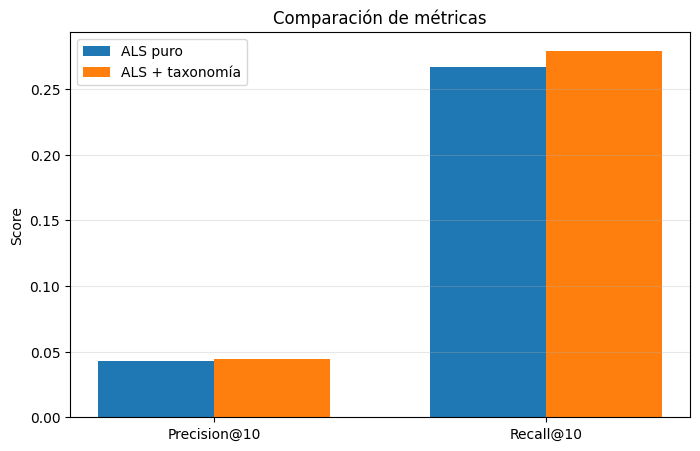

In [26]:
# ============================================================
# GRÁFICO COMPARATIVO DE MÉTRICAS
# ============================================================

import matplotlib.pyplot as plt

metrics = ["precision_at_10", "recall_at_10"]

als_values = [
    als_metrics["precision_at_k"],
    als_metrics["recall_at_k"]
]

tax_values = [
    tax_metrics["precision_at_k"],
    tax_metrics["recall_at_k"]
]

x = np.arange(len(metrics))

width = 0.35

plt.figure(figsize=(8, 5))

plt.bar(
    x - width/2,
    als_values,
    width,
    label="ALS puro"
)

plt.bar(
    x + width/2,
    tax_values,
    width,
    label="ALS + taxonomía"
)

plt.xticks(x, ["Precision@10", "Recall@10"])

plt.ylabel("Score")

plt.title("Comparación de métricas")

plt.legend()

plt.grid(axis="y", alpha=0.3)

plt.show()

#GRID SEARCH VARIANDO PESO DEL ALS CON PESO DE LA CLASIFICACIÓN PARA OPTIMIZAR MÉTRICAS (ESPECIALMENTE RECALL)

In [27]:


# ============================================================
# GRID SEARCH: PESO ALS vs PESO TAXONOMÍA
# ============================================================

alpha_values = [0.95, 0.90, 0.80, 0.70, 0.60]

grid_results = []

for alpha in alpha_values:

    beta = 1 - alpha

    print(f"\nProbando ALPHA={alpha} | BETA={beta}")

    # --------------------------------------------------------
    # Calcular score híbrido
    # --------------------------------------------------------

    temp_df = tax_candidates_df.copy()

    temp_df["score_final"] = (
        alpha * temp_df["score_base_norm"] +
        beta * temp_df["taxonomic_score"]
    )

    # --------------------------------------------------------
    # Re-ranking
    # --------------------------------------------------------

    temp_df = (
        temp_df
        .sort_values(
            by=["user_id", "score_final", "score_base_norm"],
            ascending=[True, False, False]
        )
        .copy()
    )

    temp_df["rank"] = (
        temp_df
        .groupby("user_id")
        .cumcount() + 1
    )

    topk_df = (
        temp_df[
            temp_df["rank"] <= K_FINAL
        ]
        .copy()
    )

    # --------------------------------------------------------
    # Evaluación
    # --------------------------------------------------------

    metrics = precision_recall_at_k(
        recommendations_df=topk_df,
        ground_truth=gt_temporal,
        k=K_FINAL
    )

    # --------------------------------------------------------
    # Guardar resultados
    # --------------------------------------------------------

    grid_results.append({
        "alpha_als": alpha,
        "beta_taxonomy": beta,
        "precision_at_10": metrics["precision_at_k"],
        "recall_at_10": metrics["recall_at_k"]
    })

# ============================================================
# RESULTADOS GRID SEARCH
# ============================================================

grid_results_df = pd.DataFrame(grid_results)

grid_results_df = grid_results_df.sort_values(
    by="recall_at_10",
    ascending=False
)

grid_results_df


Probando ALPHA=0.95 | BETA=0.050000000000000044

Probando ALPHA=0.9 | BETA=0.09999999999999998

Probando ALPHA=0.8 | BETA=0.19999999999999996

Probando ALPHA=0.7 | BETA=0.30000000000000004

Probando ALPHA=0.6 | BETA=0.4


,alpha_als,beta_taxonomy,precision_at_10,recall_at_10
4,0.60,0.40,0.046596,0.292840
3,0.70,0.30,0.045907,0.288026
2,0.80,0.20,0.044715,0.279212
1,0.90,0.10,0.043815,0.273813
0,0.95,0.05,0.043417,0.271445


In [28]:
# ============================================================
# GRID SEARCH EXTENDIDO
# MÁS PESO A TAXONOMÍA
# ============================================================

alpha_values = [
    0.50,
    0.40,
    0.30,
    0.20,
    0.10,
    0.00
]

extended_results = []

for alpha in alpha_values:

    beta = 1 - alpha

    print(f"\nProbando ALPHA={alpha} | BETA={beta}")

    # --------------------------------------------------------
    # Score híbrido
    # --------------------------------------------------------

    temp_df = tax_candidates_df.copy()

    temp_df["score_final"] = (
        alpha * temp_df["score_base_norm"] +
        beta * temp_df["taxonomic_score"]
    )

    # --------------------------------------------------------
    # Re-ranking
    # --------------------------------------------------------

    temp_df = (
        temp_df
        .sort_values(
            by=["user_id", "score_final", "score_base_norm"],
            ascending=[True, False, False]
        )
        .copy()
    )

    temp_df["rank"] = (
        temp_df
        .groupby("user_id")
        .cumcount() + 1
    )

    topk_df = (
        temp_df[
            temp_df["rank"] <= K_FINAL
        ]
        .copy()
    )

    # --------------------------------------------------------
    # Evaluación
    # --------------------------------------------------------

    metrics = precision_recall_at_k(
        recommendations_df=topk_df,
        ground_truth=gt_temporal,
        k=K_FINAL
    )

    # --------------------------------------------------------
    # Guardar
    # --------------------------------------------------------

    extended_results.append({
        "alpha_als": alpha,
        "beta_taxonomy": beta,
        "precision_at_10": metrics["precision_at_k"],
        "recall_at_10": metrics["recall_at_k"]
    })

# ============================================================
# RESULTADOS
# ============================================================

extended_results_df = pd.DataFrame(extended_results)

extended_results_df = extended_results_df.sort_values(
    by="recall_at_10",
    ascending=False
)

extended_results_df


Probando ALPHA=0.5 | BETA=0.5

Probando ALPHA=0.4 | BETA=0.6

Probando ALPHA=0.3 | BETA=0.7

Probando ALPHA=0.2 | BETA=0.8

Probando ALPHA=0.1 | BETA=0.9

Probando ALPHA=0.0 | BETA=1.0


,alpha_als,beta_taxonomy,precision_at_10,recall_at_10
1,0.4,0.6,0.046728,0.293424
0,0.5,0.5,0.046649,0.293295
2,0.3,0.7,0.046517,0.292825
3,0.2,0.8,0.046490,0.292739
4,0.1,0.9,0.046384,0.292708
5,0.0,1.0,0.045881,0.290865


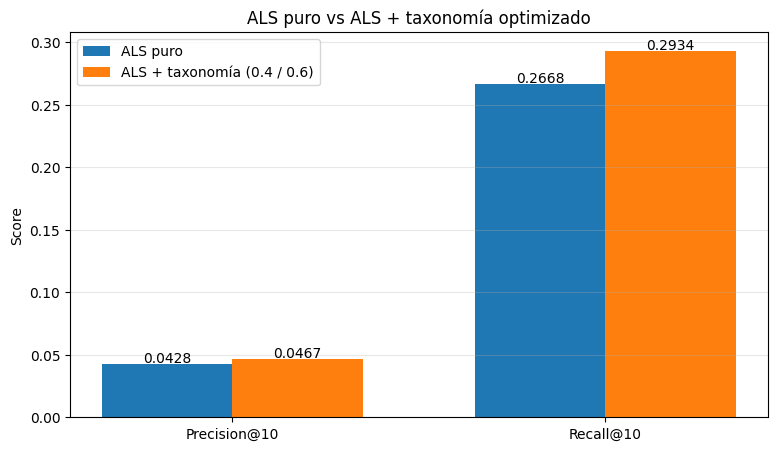

In [29]:
# ============================================================
# GRÁFICO FINAL:
# ALS PURO vs ALS + TAXONOMÍA OPTIMIZADO
# ============================================================

import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Valores ALS puro
# ------------------------------------------------------------

als_precision = als_metrics["precision_at_k"]
als_recall = als_metrics["recall_at_k"]

# ------------------------------------------------------------
# Mejor configuración híbrida encontrada
# ------------------------------------------------------------

best_row = extended_results_df.iloc[0]

hybrid_precision = best_row["precision_at_10"]
hybrid_recall = best_row["recall_at_10"]

# ------------------------------------------------------------
# Datos para gráfico
# ------------------------------------------------------------

metrics_names = ["Precision@10", "Recall@10"]

als_values = [
    als_precision,
    als_recall
]

hybrid_values = [
    hybrid_precision,
    hybrid_recall
]

x = np.arange(len(metrics_names))

width = 0.35

# ------------------------------------------------------------
# Crear figura
# ------------------------------------------------------------

plt.figure(figsize=(9, 5))

plt.bar(
    x - width/2,
    als_values,
    width,
    label="ALS puro"
)

plt.bar(
    x + width/2,
    hybrid_values,
    width,
    label="ALS + taxonomía (0.4 / 0.6)"
)

# ------------------------------------------------------------
# Etiquetas y estilo
# ------------------------------------------------------------

plt.xticks(x, metrics_names)

plt.ylabel("Score")

plt.title("ALS puro vs ALS + taxonomía optimizado")

plt.legend()

plt.grid(axis="y", alpha=0.3)

# ------------------------------------------------------------
# Mostrar valores encima de barras
# ------------------------------------------------------------

for i, v in enumerate(als_values):
    plt.text(
        i - width/2,
        v + 0.001,
        f"{v:.4f}",
        ha="center"
    )

for i, v in enumerate(hybrid_values):
    plt.text(
        i + width/2,
        v + 0.001,
        f"{v:.4f}",
        ha="center"
    )

plt.show()

In [31]:
# ============================================================
# GRID SEARCH: PESOS INTERNOS DE LA TAXONOMÍA
# ============================================================
# Mantendremos fijo:
# ALS = 0.4
# Taxonomía = 0.6
#
# Y probaremos distintas combinaciones para:
# nivel1, nivel2_norm, nivel3_norm
# ============================================================

ALPHA = 0.4
BETA = 0.6

taxonomy_weight_grid = [
    (0.6, 0.3, 0.1),
    (0.5, 0.3, 0.2),
    (0.4, 0.4, 0.2),
    (0.4, 0.3, 0.3),
    (0.3, 0.4, 0.3),
    (0.3, 0.3, 0.4),
    (0.2, 0.3, 0.5),
    (0.2, 0.4, 0.4),
    (0.1, 0.3, 0.6)
]

taxonomy_grid_results = []

for w1, w2, w3 in taxonomy_weight_grid:

    print(f"\nProbando nivel1={w1}, nivel2={w2}, nivel3={w3}")

    temp_df = tax_candidates_df.copy()

    temp_df["taxonomic_score_test"] = (
        w1 * temp_df["pref_nivel1"] +
        w2 * temp_df["pref_nivel2"] +
        w3 * temp_df["pref_nivel3"]
    )

    temp_df["score_final"] = (
        ALPHA * temp_df["score_base_norm"] +
        BETA * temp_df["taxonomic_score_test"]
    )

    temp_df = (
        temp_df
        .sort_values(
            by=["user_id", "score_final", "score_base_norm"],
            ascending=[True, False, False]
        )
        .copy()
    )

    temp_df["rank"] = (
        temp_df
        .groupby("user_id")
        .cumcount() + 1
    )

    topk_df = temp_df[temp_df["rank"] <= K_FINAL].copy()

    metrics = precision_recall_at_k(
        recommendations_df=topk_df,
        ground_truth=gt_temporal,
        k=K_FINAL
    )

    taxonomy_grid_results.append({
        "w_nivel1": w1,
        "w_nivel2": w2,
        "w_nivel3": w3,
        "precision_at_10": metrics["precision_at_k"],
        "recall_at_10": metrics["recall_at_k"]
    })

taxonomy_grid_results_df = pd.DataFrame(taxonomy_grid_results)

taxonomy_grid_results_df = taxonomy_grid_results_df.sort_values(
    by="recall_at_10",
    ascending=False
)

taxonomy_grid_results_df


Probando nivel1=0.6, nivel2=0.3, nivel3=0.1

Probando nivel1=0.5, nivel2=0.3, nivel3=0.2

Probando nivel1=0.4, nivel2=0.4, nivel3=0.2

Probando nivel1=0.4, nivel2=0.3, nivel3=0.3

Probando nivel1=0.3, nivel2=0.4, nivel3=0.3

Probando nivel1=0.3, nivel2=0.3, nivel3=0.4

Probando nivel1=0.2, nivel2=0.3, nivel3=0.5

Probando nivel1=0.2, nivel2=0.4, nivel3=0.4

Probando nivel1=0.1, nivel2=0.3, nivel3=0.6


,w_nivel1,w_nivel2,w_nivel3,precision_at_10,recall_at_10
6,0.2,0.3,0.5,0.046834,0.294040
4,0.3,0.4,0.3,0.046808,0.293779
8,0.1,0.3,0.6,0.046808,0.293758
3,0.4,0.3,0.3,0.046781,0.293735
5,0.3,0.3,0.4,0.046781,0.293615
7,0.2,0.4,0.4,0.046755,0.293603
2,0.4,0.4,0.2,0.046781,0.293483
1,0.5,0.3,0.2,0.046728,0.293424
0,0.6,0.3,0.1,0.046728,0.293389


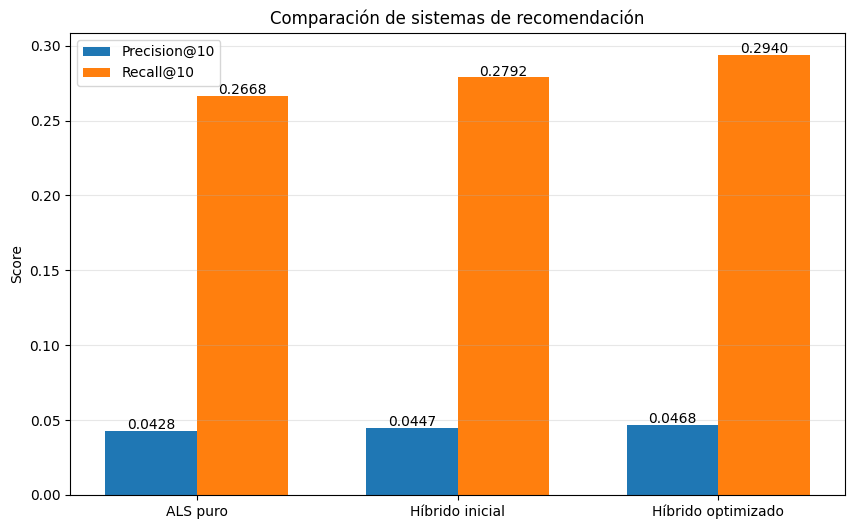

In [32]:
# ============================================================
# COMPARACIÓN FINAL DE LOS 3 SISTEMAS
# ============================================================

import matplotlib.pyplot as plt

# ------------------------------------------------------------
# ALS puro
# ------------------------------------------------------------

als_precision = als_metrics["precision_at_k"]
als_recall = als_metrics["recall_at_k"]

# ------------------------------------------------------------
# Híbrido inicial
# (0.8 ALS / 0.2 Taxonomía)
# ------------------------------------------------------------

initial_precision = 0.044715
initial_recall = 0.279212

# ------------------------------------------------------------
# Híbrido optimizado final
# (0.4 ALS / 0.6 Taxonomía)
# (0.2 / 0.3 / 0.5)
# ------------------------------------------------------------

best_row = taxonomy_grid_results_df.iloc[0]

final_precision = best_row["precision_at_10"]
final_recall = best_row["recall_at_10"]

# ------------------------------------------------------------
# Datos
# ------------------------------------------------------------

models = [
    "ALS puro",
    "Híbrido inicial",
    "Híbrido optimizado"
]

precision_values = [
    als_precision,
    initial_precision,
    final_precision
]

recall_values = [
    als_recall,
    initial_recall,
    final_recall
]

x = np.arange(len(models))

width = 0.35

# ------------------------------------------------------------
# Figura
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

plt.bar(
    x - width/2,
    precision_values,
    width,
    label="Precision@10"
)

plt.bar(
    x + width/2,
    recall_values,
    width,
    label="Recall@10"
)

# ------------------------------------------------------------
# Estilo
# ------------------------------------------------------------

plt.xticks(x, models)

plt.ylabel("Score")

plt.title("Comparación de sistemas de recomendación")

plt.legend()

plt.grid(axis="y", alpha=0.3)

# ------------------------------------------------------------
# Etiquetas numéricas
# ------------------------------------------------------------

for i, v in enumerate(precision_values):
    plt.text(
        i - width/2,
        v + 0.001,
        f"{v:.4f}",
        ha="center"
    )

for i, v in enumerate(recall_values):
    plt.text(
        i + width/2,
        v + 0.001,
        f"{v:.4f}",
        ha="center"
    )

plt.show()

AHORA, SE EVALUARÁ LA ADICIÓN DE LA CAPA DE CLASIFICACIÓN EN DOS DIVISIONES DEL DATASET: LA DE POCAS INTERACCIONES (usuarios con 5 eventos o menos), Y LA DE MUCHAS INTERACCIONES (mas de 5)

In [33]:
# ============================================================
# CONTAR INTERACCIONES POR USUARIO EN TRAIN
# ============================================================

user_interaction_counts = (
    train_ints
    .groupby("user_id")["product_id"]
    .count()
    .reset_index()
    .rename(columns={"product_id": "n_interactions"})
)

user_interaction_counts.head()

,user_id,n_interactions
0,1515915625353226922,1
1,1515915625353230067,1
2,1515915625353230683,10
3,1515915625353230922,1
4,1515915625353234047,7


In [34]:
# ============================================================
# SEGMENTAR USUARIOS
# ============================================================
# Sparse  = <= 5 interacciones
# Activos = > 5 interacciones
# ============================================================

sparse_users = set(
    user_interaction_counts[
        user_interaction_counts["n_interactions"] <= 5
    ]["user_id"]
)

active_users = set(
    user_interaction_counts[
        user_interaction_counts["n_interactions"] > 5
    ]["user_id"]
)

print("Usuarios sparse:", len(sparse_users))
print("Usuarios activos:", len(active_users))

Usuarios sparse: 331642
Usuarios activos: 4766


In [35]:
# ============================================================
# FILTRAR RECOMENDACIONES POR TIPO DE USUARIO
# ============================================================

# ALS puro
als_sparse_df = als_top10_df[
    als_top10_df["user_id"].isin(sparse_users)
].copy()

als_active_df = als_top10_df[
    als_top10_df["user_id"].isin(active_users)
].copy()

# Híbrido optimizado
hybrid_sparse_df = tax_ranked_df[
    (tax_ranked_df["rank"] <= K_FINAL) &
    (tax_ranked_df["user_id"].isin(sparse_users))
].copy()

hybrid_active_df = tax_ranked_df[
    (tax_ranked_df["rank"] <= K_FINAL) &
    (tax_ranked_df["user_id"].isin(active_users))
].copy()

In [36]:
# ============================================================
# MÉTRICAS EN USUARIOS SPARSE
# ============================================================

als_sparse_metrics = precision_recall_at_k(
    recommendations_df=als_sparse_df,
    ground_truth=gt_temporal,
    k=K_FINAL
)

hybrid_sparse_metrics = precision_recall_at_k(
    recommendations_df=hybrid_sparse_df,
    ground_truth=gt_temporal,
    k=K_FINAL
)

pd.DataFrame([
    {
        "model": "ALS puro",
        "precision_at_10": als_sparse_metrics["precision_at_k"],
        "recall_at_10": als_sparse_metrics["recall_at_k"]
    },
    {
        "model": "ALS + taxonomía",
        "precision_at_10": hybrid_sparse_metrics["precision_at_k"],
        "recall_at_10": hybrid_sparse_metrics["recall_at_k"]
    }
])

,model,precision_at_10,recall_at_10
0,ALS puro,0.037387,0.258935
1,ALS + taxonomía,0.039278,0.271997


In [37]:
# ============================================================
# MÉTRICAS EN USUARIOS ACTIVOS
# ============================================================

als_active_metrics = precision_recall_at_k(
    recommendations_df=als_active_df,
    ground_truth=gt_temporal,
    k=K_FINAL
)

hybrid_active_metrics = precision_recall_at_k(
    recommendations_df=hybrid_active_df,
    ground_truth=gt_temporal,
    k=K_FINAL
)

pd.DataFrame([
    {
        "model": "ALS puro",
        "precision_at_10": als_active_metrics["precision_at_k"],
        "recall_at_10": als_active_metrics["recall_at_k"]
    },
    {
        "model": "ALS + taxonomía",
        "precision_at_10": hybrid_active_metrics["precision_at_k"],
        "recall_at_10": hybrid_active_metrics["recall_at_k"]
    }
])

,model,precision_at_10,recall_at_10
0,ALS puro,0.097337,0.346431
1,ALS + taxonomía,0.100000,0.352576


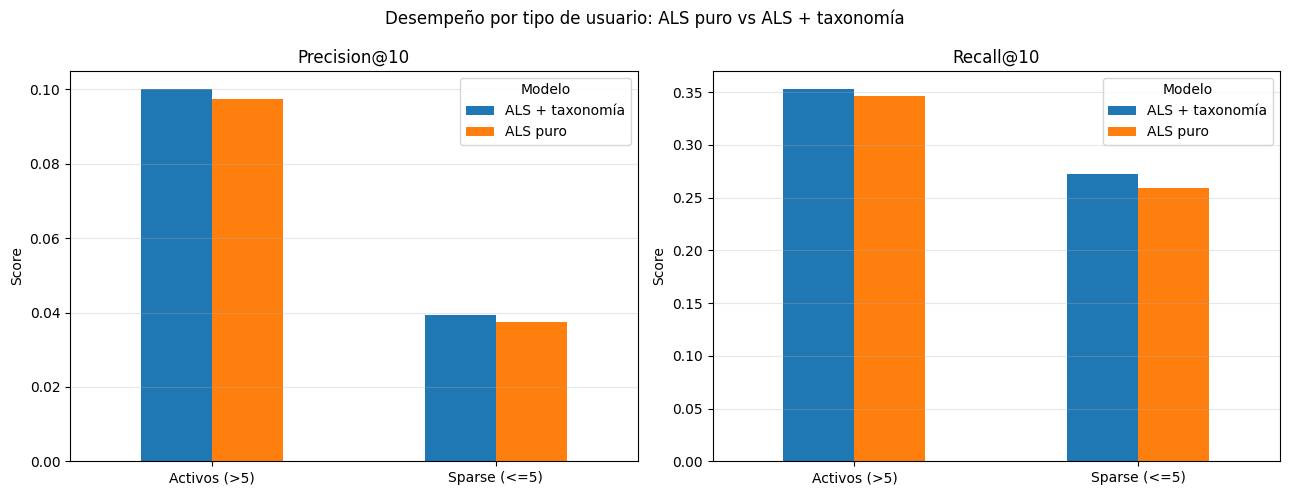

In [38]:
# ============================================================
# GRÁFICA: DESEMPEÑO POR TIPO DE USUARIO
# ALS PURO vs ALS + TAXONOMÍA
# ============================================================

segment_results_df = pd.DataFrame([
    {
        "grupo": "Sparse (<=5)",
        "modelo": "ALS puro",
        "precision_at_10": als_sparse_metrics["precision_at_k"],
        "recall_at_10": als_sparse_metrics["recall_at_k"]
    },
    {
        "grupo": "Sparse (<=5)",
        "modelo": "ALS + taxonomía",
        "precision_at_10": hybrid_sparse_metrics["precision_at_k"],
        "recall_at_10": hybrid_sparse_metrics["recall_at_k"]
    },
    {
        "grupo": "Activos (>5)",
        "modelo": "ALS puro",
        "precision_at_10": als_active_metrics["precision_at_k"],
        "recall_at_10": als_active_metrics["recall_at_k"]
    },
    {
        "grupo": "Activos (>5)",
        "modelo": "ALS + taxonomía",
        "precision_at_10": hybrid_active_metrics["precision_at_k"],
        "recall_at_10": hybrid_active_metrics["recall_at_k"]
    }
])

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

metrics = [
    ("precision_at_10", "Precision@10"),
    ("recall_at_10", "Recall@10")
]

for ax, (metric_col, metric_title) in zip(axes, metrics):
    pivot_df = segment_results_df.pivot(
        index="grupo",
        columns="modelo",
        values=metric_col
    )

    pivot_df.plot(
        kind="bar",
        ax=ax
    )

    ax.set_title(metric_title)
    ax.set_xlabel("")
    ax.set_ylabel("Score")
    ax.grid(axis="y", alpha=0.3)
    ax.legend(title="Modelo")
    ax.tick_params(axis="x", rotation=0)

plt.suptitle("Desempeño por tipo de usuario: ALS puro vs ALS + taxonomía")
plt.tight_layout()
plt.show()